In [2]:
import random
import numpy as np
from osgeo import gdal
from osgeo import gdalconst
from osgeo.gdalconst import *
try:
            from osgeo import ogr
except:
            import ogr
from sklearn.model_selection import RepeatedKFold
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split,cross_val_score,cross_validate,GridSearchCV
from sklearn import preprocessing
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,recall_score,f1_score,classification_report,roc_curve,auc

import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier

import pandas as pd
import cv2

# 读取真实结果

In [433]:
path = r'E:\eaasy\Thesis\水体边界提取文章_apply science\副本\修改资料\Data\Data2019_10_20\TrueClassificationResult\TrueResultArea2\Area1TrueResultFromMajority3X3.dat'
#gdal.Register()
dataset = gdal.Open(path)    

geoTransform = dataset.GetGeoTransform()

proj = dataset.GetProjection()

cols = dataset.RasterXSize

rows = dataset.RasterYSize

band = dataset.GetRasterBand(1)


y_true = band.ReadAsArray(0,0,cols,rows)


In [218]:
y_true.dtype

dtype('uint16')

In [219]:
print( y_true.shape[0] , y_true.shape[1])

4918 2742


In [220]:
y_true.max()

256

In [434]:
y_true = np.array(y_true,dtype=np.int16) 

In [222]:
count1 = 0
count2 = 0
count256 = 0
count0 = 0
for i in range(0,y_true.shape[0]):
    for j in range(0,y_true.shape[1]):
        if y_true[i][j] == 2 :
            count2 += 1
        elif y_true[i][j] == 1:
            count1 += 1

        elif y_true[i][j] == 256:
            count256 += 1

print(count1,count2,count256)

108580 270306 13106270


In [224]:
count1 + count2 + count256 -  y_true.shape[0] * y_true.shape[1]

0

In [367]:
for i in range(0,y_true.shape[0]):
    for j in range(0,y_true.shape[1]):
        if y_true[i][j] == 2 :
            y_true[i][j] = -1


In [368]:
y_true_c = []

In [369]:
for i in range(0,y_true.shape[0]):
    for j in range(0,y_true.shape[1]):
        if y_true[i][j] ==256 :
            continue
        else:
            y_true_c.append(y_true[i][j])


In [370]:
y_true_c = np.array(y_true_c,dtype='int16').reshape(-1,1)

In [371]:
print(y_true_c.min(),y_true_c.max())

-1 1


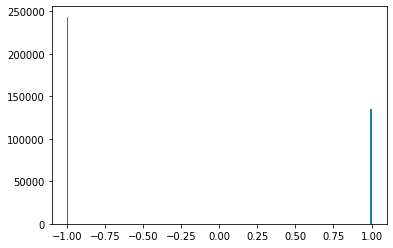

In [372]:

plt.hist(y_true_c.ravel(), 256)
plt.show()

# 读取预测结果

In [380]:
path = r'E:\eaasy\Thesis\水体边界提取文章_apply science\副本\修改资料\Data\Data2019_10_04\ProcessData\ClassificationResult_area1\mlpPredictResult.tif'

#gdal.Register()
dataset = gdal.Open(path)    

geoTransform = dataset.GetGeoTransform()

proj = dataset.GetProjection()

cols = dataset.RasterXSize

rows = dataset.RasterYSize

band = dataset.GetRasterBand(1)


mlp = band.ReadAsArray(0,0,cols,rows)

mlp = np.array(mlp,dtype='int16') 

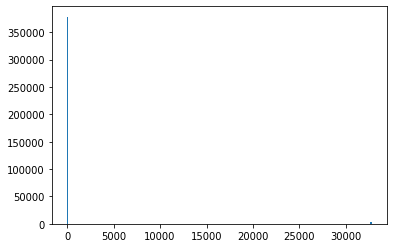

In [381]:

plt.hist(mlp.ravel(), 256)
plt.show()

In [382]:
mlp.max()

32767

In [383]:
mlp_c = []
for i in range(0,mlp.shape[0]):
    for j in range(0,mlp.shape[1]):
        
        if mlp[i][j] == 0 or mlp[i][j] == 256 or mlp[i][j] == 32767 :
            continue
        else:
            if mlp[i][j] == 1:
                mlp_c.append(-1)
            else:
                mlp_c.append(1)


In [384]:
mlp_c = np.array(mlp_c,dtype='int16').reshape(-1,1)

In [385]:
mlp_fpr,mlp_tpr,mlp_threshold = roc_curve(mlp_c,y_true_c)
mlp_roc_auc =  auc(mlp_fpr,mlp_tpr)


In [386]:
mlp_roc_auc

0.6877140432310976

In [387]:
labels = [1,-1]

classes = ['water','other']
print(classification_report(y_true_c
                            ,mlp_c
                            ,target_names = classes
                            ,labels = labels
                            ,digits = 3))

              precision    recall  f1-score   support

       water      0.379     0.999     0.550    134530
       other      0.996     0.097     0.177    243694

    accuracy                          0.418    378224
   macro avg      0.688     0.548     0.363    378224
weighted avg      0.777     0.418     0.310    378224



# 随机森林

In [395]:
path = r'E:\eaasy\Thesis\水体边界提取文章_apply science\副本\修改资料\Data\Data2019_10_04\ProcessData\ClassificationResult_area1\RandomForestPredictResult.tif'

#gdal.Register()
dataset = gdal.Open(path)    

geoTransform = dataset.GetGeoTransform()

proj = dataset.GetProjection()

cols = dataset.RasterXSize

rows = dataset.RasterYSize

band = dataset.GetRasterBand(1)


rfc= band.ReadAsArray(0,0,cols,rows)

rfc = np.array(rfc,dtype='int16') 

In [152]:
print(rfc.max(),rfc.min())

1 -1


In [241]:
print(rfc.shape[0],rfc.shape[1])

4918 2742


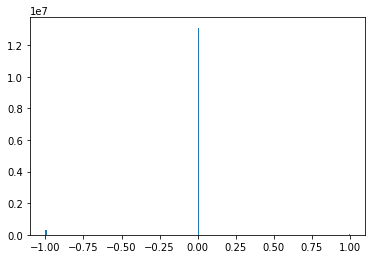

In [242]:
plt.hist(rfc.ravel(), 256)
plt.show()

In [155]:
count = 0
for i in range(0,rfc.shape[0]):
    for j in range(0,rfc.shape[1]):
        
        if rfc[i][j] ==0  :
            count += 1

count


2464

In [396]:
rfc_c = []
for i in range(0,rfc.shape[0]):
    for j in range(0,rfc.shape[1]):
        
        if rfc[i][j] == 0 or rfc[i][j] == 256  or rfc[i][j] == 32767:
            continue
        else:
            if rfc[i][j] == 1:
                rfc_c.append(-1)
            else:
                rfc_c.append(1)
            

In [397]:
rfc_c = np.array(rfc_c,dtype='int16').reshape(-1,1)

In [398]:
rfc_fpr,rfc_tpr,rfc_threshold = roc_curve(rfc_c,y_true_c)
rfc_roc_auc =  auc(rfc_fpr,rfc_tpr)

print(rfc_roc_auc)

0.688242119852463


In [399]:
labels = [1,-1]

classes = ['water','other']
print(classification_report(y_true_c
                            ,rfc_c
                            ,target_names = classes
                            ,labels = labels
                            ,digits = 3))

              precision    recall  f1-score   support

       water      0.377     1.000     0.547    134530
       other      1.000     0.087     0.160    243694

    accuracy                          0.412    378224
   macro avg      0.688     0.544     0.354    378224
weighted avg      0.778     0.412     0.298    378224



# svm

In [400]:
path = r'E:\eaasy\Thesis\水体边界提取文章_apply science\副本\修改资料\Data\Data2019_10_04\ProcessData\ClassificationResult_area1\svmPredictResult.tif'

#gdal.Register()
dataset = gdal.Open(path)    

geoTransform = dataset.GetGeoTransform()

proj = dataset.GetProjection()

cols = dataset.RasterXSize

rows = dataset.RasterYSize

band = dataset.GetRasterBand(1)


svm = band.ReadAsArray(0,0,cols,rows)

svm = np.array(svm,dtype='int16') 

In [166]:
print(svm.max(),svm.min())

1 -1


In [167]:
print(svm.shape[0],svm.shape[1])

618 616


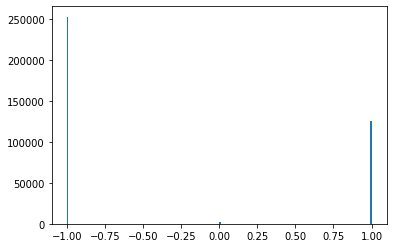

In [168]:
plt.hist(svm.ravel(), 256)
plt.show()

In [169]:
count = 0
for i in range(0,svm.shape[0]):
    for j in range(0,svm.shape[1]):
        
        if rfc[i][j] ==0 :
            count += 1

count


2464

In [401]:
svm_c = []
for i in range(0,svm.shape[0]):
    for j in range(0,svm.shape[1]):
        
        if svm[i][j] == 0  or svm[i][j] == 256 or  svm[i][j] == 32767 :
            continue
        else:
            svm_c.append(svm[i][j])

In [402]:
svm_c = np.array(svm_c,dtype='int16').reshape(-1,1)

In [403]:
svm_fpr,svm_tpr,svm_threshold = roc_curve(svm_c,y_true_c)
svm_roc_auc =  auc(svm_fpr,svm_tpr)

print(svm_roc_auc)

0.3313558472125921


In [404]:
labels = [1,-1]

classes = ['water','other']
print(classification_report(y_true_c
                            ,svm_c
                            ,target_names = classes
                            ,labels = labels
                            ,digits = 3))

              precision    recall  f1-score   support

       water      0.020     0.000     0.000    134530
       other      0.643     0.994     0.781    243694

    accuracy                          0.640    378224
   macro avg      0.331     0.497     0.391    378224
weighted avg      0.421     0.640     0.503    378224



# xbgoost

In [405]:
path = r'E:\eaasy\Thesis\水体边界提取文章_apply science\副本\修改资料\Data\Data2019_10_04\ProcessData\ClassificationResult_area1\xgboostPredictResult.tif'

#gdal.Register()
dataset = gdal.Open(path)    

geoTransform = dataset.GetGeoTransform()

proj = dataset.GetProjection()

cols = dataset.RasterXSize

rows = dataset.RasterYSize

band = dataset.GetRasterBand(1)


xgboost = band.ReadAsArray(0,0,cols,rows)

xgboost = np.array(xgboost,dtype='int16') 

In [406]:
print(xgboost.max(),xgboost.min())

1 -1


In [176]:
print(xgboost.shape[0],xgboost.shape[1])

618 616


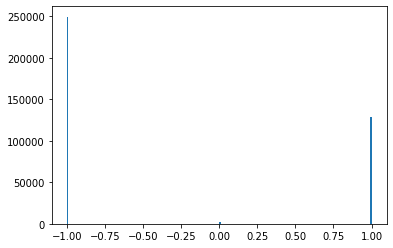

In [177]:
plt.hist(xgboost.ravel(), 256)
plt.show()

In [178]:
count = 0
for i in range(0,xgboost.shape[0]):
    for j in range(0,xgboost.shape[1]):
        
        if xgboost[i][j] ==0 :
            count += 1

count


2464

In [407]:
xgboost_c = []
for i in range(0,xgboost.shape[0]):
    for j in range(0,xgboost.shape[1]):
        
        if xgboost[i][j] == 0 or xgboost[i][j] == 256  or  xgboost[i][j] == 32767:
            continue
        else:
            if xgboost[i][j] ==-1:
                xgboost_c.append(1)
            else:
                xgboost_c.append(-1)


In [408]:
xgboost_c = np.array(xgboost_c,dtype='int16').reshape(-1,1)

In [409]:
xgboost_fpr,xgboost_tpr,xgboost_threshold = roc_curve(xgboost_c,y_true_c)
xgboost_roc_auc =  auc(xgboost_fpr,xgboost_tpr)

print(xgboost_roc_auc)

0.7176235509090526


In [410]:
labels = [1,-1]

classes = ['water','other']
print(classification_report(y_true_c
                            ,xgboost_c
                            ,target_names = classes
                            ,labels = labels
                            ,digits = 3))

              precision    recall  f1-score   support

       water      0.435     1.000     0.607    134530
       other      1.000     0.284     0.442    243694

    accuracy                          0.539    378224
   macro avg      0.718     0.642     0.524    378224
weighted avg      0.799     0.539     0.501    378224



# 逻辑回归

In [411]:
path = r'E:\eaasy\Thesis\水体边界提取文章_apply science\副本\修改资料\Data\Data2019_10_04\ProcessData\ClassificationResult_area1\LogisticRegressionPredictResult.tif'

#gdal.Register()
dataset = gdal.Open(path)    

geoTransform = dataset.GetGeoTransform()

proj = dataset.GetProjection()

cols = dataset.RasterXSize

rows = dataset.RasterYSize

band = dataset.GetRasterBand(1)


lr = band.ReadAsArray(0,0,cols,rows)

lr = np.array(lr,dtype='int16') 

In [184]:
count = 0
for i in range(0,lr.shape[0]):
    for j in range(0,lr.shape[1]):
        
        if lr[i][j] ==0 :
            count += 1

count


2464

In [412]:
lr_c = []
for i in range(0,lr.shape[0]):
    for j in range(0,lr.shape[1]):
        
        if lr[i][j] == 0 or lr[i][j] == 256 or lr[i][j] == 32767:
            continue
        else:
           
             
                lr_c.append(lr[i][j])
            

In [413]:
lr_c = np.array(lr_c,dtype='int16').reshape(-1,1)

In [414]:
lr_fpr,lr_tpr,lr_threshold = roc_curve(lr_c,y_true_c)
lr_roc_auc =  auc(lr_fpr,lr_tpr)

print(lr_roc_auc)

0.3294980785393502


In [415]:
labels = [1,-1]

classes = ['water','other']
print(classification_report(y_true_c
                            ,lr_c
                            ,target_names = classes
                            ,labels = labels
                            ,digits = 3))

              precision    recall  f1-score   support

       water      0.017     0.000     0.001    134530
       other      0.642     0.990     0.779    243694

    accuracy                          0.638    378224
   macro avg      0.329     0.495     0.390    378224
weighted avg      0.420     0.638     0.502    378224



# dt

In [416]:
path = r'E:\eaasy\Thesis\水体边界提取文章_apply science\副本\修改资料\Data\Data2019_10_04\ProcessData\ClassificationResult_area1\DecisionTreePredictResult.tif'

#gdal.Register()
dataset = gdal.Open(path)    

geoTransform = dataset.GetGeoTransform()

proj = dataset.GetProjection()

cols = dataset.RasterXSize

rows = dataset.RasterYSize

band = dataset.GetRasterBand(1)


dt = band.ReadAsArray(0,0,cols,rows)

dt = np.array(dt,dtype='int16') 

In [190]:
count = 0
for i in range(0,dt.shape[0]):
    for j in range(0,dt.shape[1]):
        
        if dt[i][j] ==0 :
            count += 1

count


2464

In [417]:
dt_c = []
for i in range(0,dt.shape[0]):
    for j in range(0,dt.shape[1]):
        
        if dt[i][j] == 0 :
            continue
        else:
            if dt[i][j] == -1:
                dt_c.append(1)
            else:
                dt_c.append(-1)
            
            

dt_c = np.array(dt_c,dtype='int16').reshape(-1,1)


In [418]:
dt_fpr,dt_tpr,dt_threshold = roc_curve(dt_c,y_true_c)
dt_roc_auc =  auc(dt_fpr,dt_tpr)

print(dt_roc_auc)

0.7895397921188312


In [419]:
labels = [1,-1]

classes = ['water','other']
print(classification_report(y_true_c
                            ,dt_c
                            ,target_names = classes
                            ,labels = labels
                            ,digits = 3))

              precision    recall  f1-score   support

       water      0.579     1.000     0.734    134530
       other      1.000     0.599     0.749    243694

    accuracy                          0.742    378224
   macro avg      0.790     0.799     0.741    378224
weighted avg      0.850     0.742     0.744    378224



# 阈值

In [420]:
path = r'E:\eaasy\Thesis\水体边界提取文章_apply science\副本\修改资料\Data\Data2019_10_04\ProcessData\ClassificationResult_area1\AdaptiveThresholdResult.tif'

#gdal.Register()
dataset = gdal.Open(path)    

geoTransform = dataset.GetGeoTransform()

proj = dataset.GetProjection()

cols = dataset.RasterXSize

rows = dataset.RasterYSize

band = dataset.GetRasterBand(1)


adaptive = band.ReadAsArray(0,0,cols,rows)

adaptive = np.array(adaptive,dtype='int16') 

In [421]:
print(adaptive.max(),adaptive.min())

32767 -1


In [ ]:
print(adaptive.shape[0],adaptive.shape[1])

In [199]:
count1 = 0
count_1 = 0;
for i in range(0,adaptive.shape[0]):
    for j in range(0,adaptive.shape[1]):
        
        if adaptive[i][j] ==1 :
            count1 += 1
        elif adaptive[i][j] == -1 :
            count_1 += 1

print(count1 ,count_1) 
print(adaptive.shape[0]* adaptive.shape[1] - count1 - count_1)

240460 137764
2464


In [422]:
adaptive_c = []
for i in range(0,adaptive.shape[0]):
    for j in range(0,adaptive.shape[1]):
        
        if adaptive[i][j] == 0 or adaptive[i][j] == 32767:
            continue
        else:
            adaptive_c.append(adaptive[i][j])
            

adaptive_c = np.array(adaptive_c,dtype='int16').reshape(-1,1)


In [423]:
adaptive_fpr,adaptive_tpr,adaptive_threshold = roc_curve(adaptive_c,y_true_c)
adaptive_roc_auc =  auc(adaptive_fpr,adaptive_tpr)

print(adaptive_roc_auc)

0.7029820233756899


In [424]:
labels = [1,-1]

classes = ['water','other']
print(classification_report(y_true_c
                            ,adaptive_c
                            ,target_names = classes
                            ,labels = labels
                            ,digits = 3))

              precision    recall  f1-score   support

       water      0.493     0.918     0.641    134530
       other      0.913     0.478     0.628    243694

    accuracy                          0.635    378224
   macro avg      0.703     0.698     0.634    378224
weighted avg      0.764     0.635     0.633    378224



## CustomThreshold

In [425]:
path = r'E:\eaasy\Thesis\水体边界提取文章_apply science\副本\修改资料\Data\Data2019_10_04\ProcessData\ClassificationResult_area1\CustomThresholdResult.tif'

#gdal.Register()
dataset = gdal.Open(path)    

geoTransform = dataset.GetGeoTransform()

proj = dataset.GetProjection()

cols = dataset.RasterXSize

rows = dataset.RasterYSize

band = dataset.GetRasterBand(1)


custom = band.ReadAsArray(0,0,cols,rows)

custom = np.array(custom,dtype='int16') 

In [426]:
custom_c = []
for i in range(0,custom.shape[0]):
    for j in range(0,custom.shape[1]):
        
        if custom[i][j] == 0 or custom[i][j] == 32767:
            continue
        else:
            custom_c.append(custom[i][j])
            

custom_c = np.array(custom_c,dtype='int16').reshape(-1,1)


In [427]:
custom_fpr,custom_tpr,custom_threshold = roc_curve(custom_c,y_true_c)
custom_roc_auc =  auc(custom_fpr,custom_tpr)

print(custom_roc_auc)

0.8415992298135652


In [428]:
labels = [1,-1]

classes = ['water','other']
print(classification_report(y_true_c
                            ,custom_c
                            ,target_names = classes
                            ,labels = labels
                            ,digits = 3))

              precision    recall  f1-score   support

       water      0.685     0.998     0.812    134530
       other      0.999     0.746     0.854    243694

    accuracy                          0.836    378224
   macro avg      0.842     0.872     0.833    378224
weighted avg      0.887     0.836     0.839    378224



## oust

In [429]:
path = r'E:\eaasy\Thesis\水体边界提取文章_apply science\副本\修改资料\Data\Data2019_10_04\ProcessData\ClassificationResult_area1\OustThresholdResult.tif'

#gdal.Register()
dataset = gdal.Open(path)    

geoTransform = dataset.GetGeoTransform()

proj = dataset.GetProjection()

cols = dataset.RasterXSize

rows = dataset.RasterYSize

band = dataset.GetRasterBand(1)


oust = band.ReadAsArray(0,0,cols,rows)

oust = np.array(oust,dtype='int16') 

In [430]:
oust_c = []
for i in range(0,oust.shape[0]):
    for j in range(0,oust.shape[1]):
        
        if oust[i][j] == 0 or oust[i][j] == 32767:
            continue
        else:
            oust_c.append(oust[i][j])
            

oust_c = np.array(oust_c,dtype='int16').reshape(-1,1)


In [431]:
oust_fpr,oust_tpr,oust_threshold = roc_curve(oust_c,y_true_c)
oust_roc_auc =  auc(oust_fpr,oust_tpr)

print(oust_roc_auc)

0.970250418620729


In [432]:
labels = [1,-1]

classes = ['water','other']
print(classification_report(y_true_c
                            ,oust_c
                            ,target_names = classes
                            ,labels = labels
                            ,digits = 3))

              precision    recall  f1-score   support

       water      0.949     0.985     0.967    134530
       other      0.992     0.971     0.981    243694

    accuracy                          0.976    378224
   macro avg      0.970     0.978     0.974    378224
weighted avg      0.976     0.976     0.976    378224

